# QEI V1

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pioemu import clock_cycles_reached, emulate, State

## Introduction

This notebook demonstrates the emulation of a PIO program for the Raspberry Pi Foundation's RP2040 Microcontroller. 

## PIO Program

Below is the PIO program that will be emulated. Try changing it and observing the results!

In [2]:
program = [
    0xa0a0, #  0: mov    pc, pins                   
    0x0004, #  1: jmp    4                          
    0x0006, #  2: jmp    6                          
    0x0008, #  3: jmp    8                          
    0xe021, #  4: set    x, 1                       
    0xa0a0, #  5: mov    pc, pins                   
    0xe020, #  6: set    x, 0                       
    0xa04a, #  7: mov    y, !y                      
    0x0089, #  8: jmp    y--, 9                     
    0xa04a, #  9: mov    y, !y                      
    0x000d, # 10: jmp    13                         
    0x008c, # 11: jmp    y--, 12                    
    0x000d, # 12: jmp    13                         
    0x4040, # 13: in     y, 32                      
    0x2020, # 14: wait   0 pin, 0                   
    0x2021, # 15: wait   0 pin, 1                   
    0x0000, # 16: jmp    0   
]

## Emulation

In [ ]:
qei_stepcpounter = [
    (state.clock, state.pin_values & 0x01)
    for _, state in emulate(program, stop_when=clock_cycles_reached(256 + 1))
]

## Output on Pin GP0

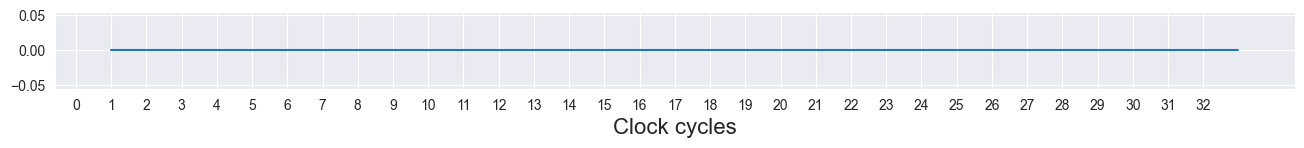

In [4]:
x_values = [clock for clock, logic_level in pin_value_series]
y_values = [logic_level for clock, logic_level in pin_value_series]

sns.set_style("darkgrid")
figure = plt.figure(figsize=(16, 1))
plot = sns.lineplot(x=x_values, y=y_values, drawstyle="steps-pre")
plot.set_xlabel("Clock cycles", fontsize = 16)
_ = plot.set_xticks(range(0, x_values[-1]))